# TDT4265 — Snow Pole Detection: Exploratory Data Analysis

This notebook walks through the full EDA pipeline for the **Poles2025** dataset.
Each section produces findings that directly justify model and augmentation decisions.

**Sections:**
1. Settings & imports
2. Dataset inventory
3. Poles per image
4. Bounding box statistics (size, aspect ratio, scale)
5. Spatial heatmap
6. Image quality (blur + brightness)
7. Sample visualisation with labels
8. Summary & model decision table
f#%% md
## 1. Settings & Imports

In [1]:
from snowpole_detector.settings import get_settings

settings = get_settings()

In [18]:
import os
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor"  : "#0d0f14",
    "axes.facecolor"    : "#161b24",
    "axes.edgecolor"    : "#2a3040",
    "axes.labelcolor"   : "#c8c4bb",
    "text.color"        : "#c8c4bb",
    "xtick.color"       : "#7a8295",
    "ytick.color"       : "#7a8295",
    "grid.color"        : "#1e2533",
    "grid.linewidth"    : 0.5,
    "axes.grid"         : True,
    "font.family"       : "monospace",
    "axes.titlecolor"   : "#ef9f27",
    "axes.titlesize"    : 13,
    "axes.labelsize"    : 11,
})

ACCENT  = "#ef9f27"   # amber
ACCENT2 = "#1d9e75"   # teal
DANGER  = "#d85a30"   # coral
MUTED   = "#4a5568"

DATASET_ROOT = Path(settings.DATASET_SOURCE)
SPLITS = ["train", "valid"]
SEED   = 42
random.seed(SEED)
np.random.seed(SEED)

print("Imports OK.")

Imports OK.


## 2. Dataset Inventory

Count images and labels per split. Check that every image has a corresponding label file.

In [19]:
def load_split(split: str) -> pd.DataFrame:
    """
    Returns a DataFrame with one row per image.
    Columns: split, stem, img_path, width, height, n_poles,
             boxes (list of (cx,cy,w,h)),
             has_label
    """
    image_dir = DATASET_ROOT / "images" / split
    label_dir = DATASET_ROOT / "labels" / split
    rows = []

    img_paths = sorted([
        p for p in image_dir.glob("*.*")
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ])

    for img_path in tqdm(img_paths, desc=f"Loading {split}"):
        lbl_path = label_dir / (img_path.stem + ".txt")
        boxes = []
        has_label = lbl_path.exists()
        if has_label:
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        _, cx, cy, w, h = map(float, parts)
                        boxes.append((cx, cy, w, h))

        with Image.open(img_path) as img:
            W, H = img.size

        rows.append({
            "split"    : split,
            "stem"     : img_path.stem,
            "img_path" : img_path,
            "width"    : W,
            "height"   : H,
            "n_poles"  : len(boxes),
            "boxes"    : boxes,
            "has_label": has_label,
        })

    return pd.DataFrame(rows)


dfs = {split: load_split(split) for split in SPLITS}
df_all = pd.concat(dfs.values(), ignore_index=True)


Loading train: 100%|██████████| 322/322 [00:00<00:00, 26934.82it/s]

Loading valid: 100%|██████████| 92/92 [00:00<00:00, 25065.02it/s]


In [20]:
# ── Inventory summary ─────────────────────────────────────────────────────────
summary = df_all.groupby("split").agg(
    images     = ("stem", "count"),
    total_poles= ("n_poles", "sum"),
    mean_poles = ("n_poles", "mean"),
    empty_imgs = ("n_poles", lambda x: (x == 0).sum()),
    no_label   = ("has_label", lambda x: (~x).sum()),
).round(2)

print("\n── Dataset inventory ──")
print(summary.to_string())
print("\nNOTE: Images without a label file are background/hard-negatives.")


── Dataset inventory ──
       images  total_poles  mean_poles  empty_imgs  no_label
split                                                       
train     322          392        1.22           0         0
valid      92          113        1.23           0         0

NOTE: Images without a label file are background/hard-negatives.


## 3. Poles per Image

**What this tells us:** Images with zero poles are *hard negatives* — the model must learn to predict nothing. A high fraction of empty images may cause a low-precision model (lots of false positives) unless handled carefully.

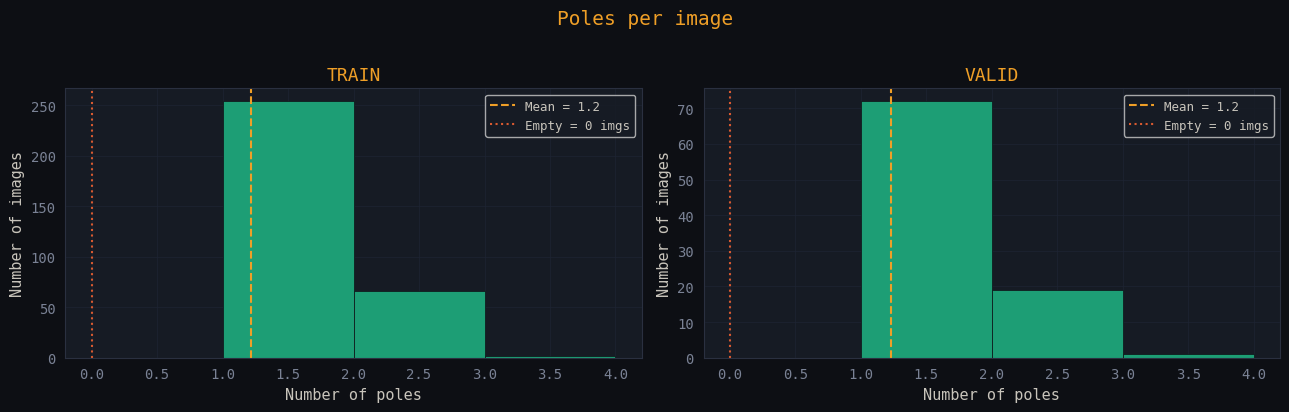

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Poles per image", color=ACCENT, fontsize=14, y=1.02)

for ax, split in zip(axes, SPLITS):
    counts = dfs[split]["n_poles"]
    max_c  = int(counts.max())
    bins   = range(0, max_c + 2)

    ax.hist(counts, bins=bins, color=ACCENT2, edgecolor="#0d0f14", linewidth=0.5)
    ax.axvline(counts.mean(), color=ACCENT, linestyle="--",
               label=f"Mean = {counts.mean():.1f}")
    ax.axvline(0, color=DANGER, linestyle=":",
               label=f"Empty = {(counts==0).sum()} imgs")

    ax.set_title(f"{split.upper()}")
    ax.set_xlabel("Number of poles")
    ax.set_ylabel("Number of images")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("eda_poles_per_image.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Bounding Box Statistics

**What this tells us:**
- **Width/height scatter** — are all poles thin and tall? Outliers = mislabelled boxes worth inspecting.
- **Aspect ratio** — w/h < 1 means taller than wide (expected). Tells us not to apply vertical flip.
- **Scale distribution** — if most poles are tiny (√area < 0.05), we need 1280px input resolution.

In [22]:
# Explode boxes into a per-box DataFrame
box_rows = []
for _, row in df_all.iterrows():
    for (cx, cy, w, h) in row["boxes"]:
        box_rows.append({
            "split"  : row["split"],
            "cx"     : cx,  "cy": cy,
            "w"      : w,   "h" : h,
            "aspect" : w / (h + 1e-6),
            "area"   : w * h,
            "scale"  : np.sqrt(w * h),   # normalised scale
            # Pixel area using image dimensions
            "w_px"   : w * row["width"],
            "h_px"   : h * row["height"],
        })

boxes_df = pd.DataFrame(box_rows)
print(f"Total bounding boxes: {len(boxes_df)}")
print(boxes_df[["w","h","aspect","scale"]].describe().round(4))

Total bounding boxes: 505
              w         h    aspect     scale
count  505.0000  505.0000  505.0000  505.0000
mean     0.0089    0.1198    0.0744    0.0316
std      0.0086    0.0727    0.0371    0.0221
min      0.0019    0.0524    0.0169    0.0106
25%      0.0047    0.0725    0.0509    0.0192
50%      0.0063    0.0941    0.0659    0.0243
75%      0.0092    0.1397    0.0863    0.0352
max      0.0767    0.4358    0.2455    0.1810


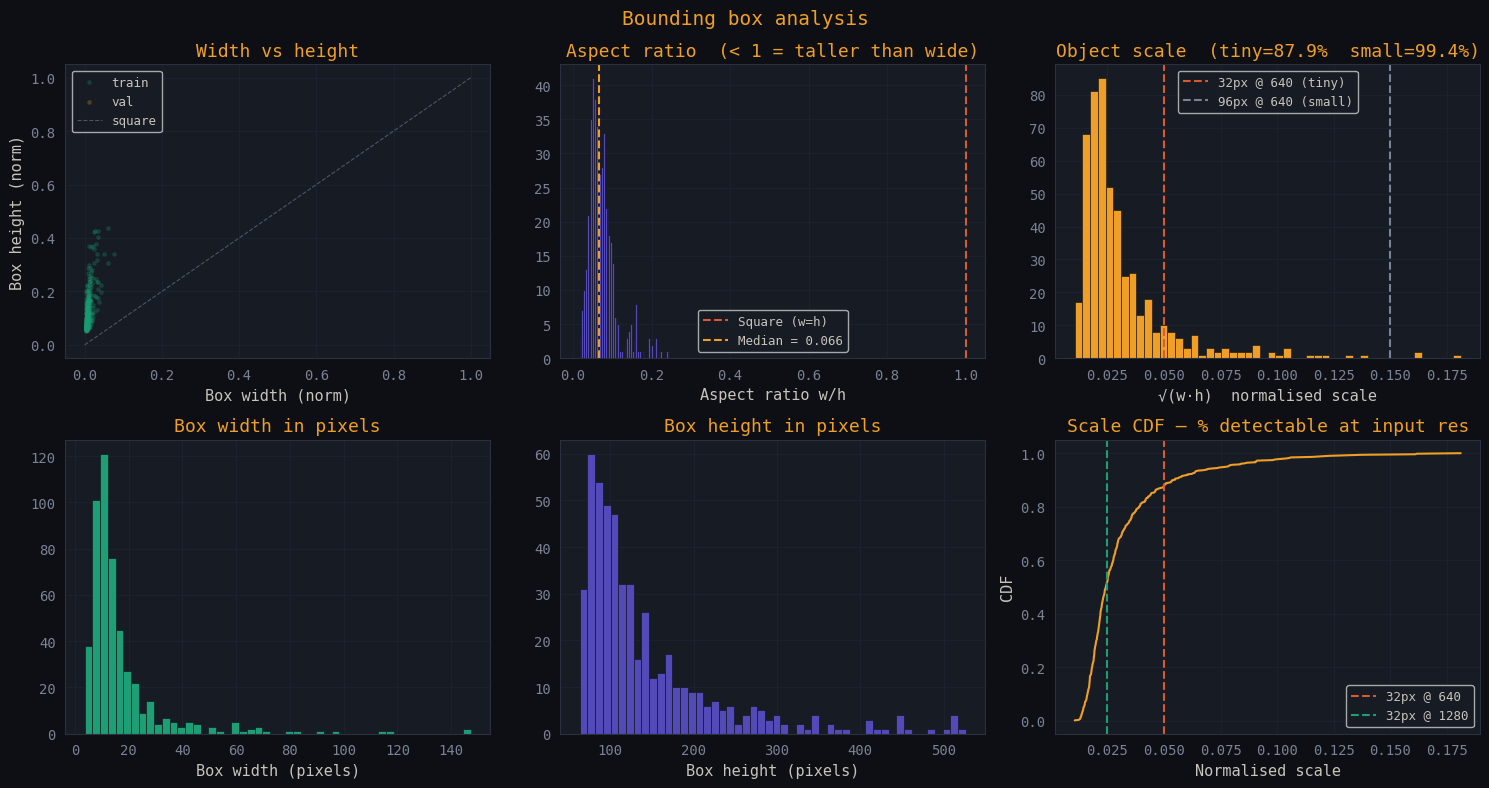


  Tiny poles  (< 32px at 640 input): 87.9%
  Small poles (< 96px at 640 input): 99.4%
  → RECOMMENDATION: Use imgsz=1280 for training and inference.


In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Bounding box analysis", color=ACCENT, fontsize=14)

# ── W vs H scatter ────────────────────────────────────────────────────────────
ax = axes[0, 0]
for split, color in [("train", ACCENT2), ("val", ACCENT)]:
    sub = boxes_df[boxes_df["split"] == split]
    ax.scatter(sub["w"], sub["h"], alpha=0.2, s=6, color=color, label=split)
ax.plot([0, 1], [0, 1], color=MUTED, linestyle="--", linewidth=0.8, label="square")
ax.set_xlabel("Box width (norm)")
ax.set_ylabel("Box height (norm)")
ax.set_title("Width vs height")
ax.legend(fontsize=9)

# ── Aspect ratio histogram ────────────────────────────────────────────────────
ax = axes[0, 1]
ax.hist(boxes_df["aspect"], bins=50, color="#534ab7", edgecolor="#0d0f14", linewidth=0.4)
ax.axvline(1.0, color=DANGER, linestyle="--", label="Square (w=h)")
ax.axvline(boxes_df["aspect"].median(), color=ACCENT, linestyle="--",
           label=f"Median = {boxes_df['aspect'].median():.3f}")
ax.set_xlabel("Aspect ratio w/h")
ax.set_title("Aspect ratio  (< 1 = taller than wide)")
ax.legend(fontsize=9)

# ── Scale distribution ────────────────────────────────────────────────────────
ax = axes[0, 2]
ax.hist(boxes_df["scale"], bins=50, color=ACCENT, edgecolor="#0d0f14", linewidth=0.4)
# YOLO small-object thresholds at 640px input
ax.axvline(32/640,  color=DANGER,  linestyle="--", label="32px @ 640 (tiny)")
ax.axvline(96/640,  color="#7a8295", linestyle="--", label="96px @ 640 (small)")
tiny_pct  = (boxes_df["scale"] < 32/640).mean() * 100
small_pct = (boxes_df["scale"] < 96/640).mean() * 100
ax.set_xlabel("√(w·h)  normalised scale")
ax.set_title(f"Object scale  (tiny={tiny_pct:.1f}%  small={small_pct:.1f}%)")
ax.legend(fontsize=9)

# ── Width pixel distribution ──────────────────────────────────────────────────
ax = axes[1, 0]
ax.hist(boxes_df["w_px"], bins=50, color=ACCENT2, edgecolor="#0d0f14", linewidth=0.4)
ax.set_xlabel("Box width (pixels)")
ax.set_title("Box width in pixels")

# ── Height pixel distribution ─────────────────────────────────────────────────
ax = axes[1, 1]
ax.hist(boxes_df["h_px"], bins=50, color="#534ab7", edgecolor="#0d0f14", linewidth=0.4)
ax.set_xlabel("Box height (pixels)")
ax.set_title("Box height in pixels")

# ── Scale CDF ─────────────────────────────────────────────────────────────────
ax = axes[1, 2]
sorted_scale = np.sort(boxes_df["scale"])
cdf = np.arange(1, len(sorted_scale)+1) / len(sorted_scale)
ax.plot(sorted_scale, cdf, color=ACCENT, linewidth=1.5)
ax.axvline(32/640, color=DANGER, linestyle="--", label="32px @ 640")
ax.axvline(32/1280, color=ACCENT2, linestyle="--", label="32px @ 1280")
ax.set_xlabel("Normalised scale")
ax.set_ylabel("CDF")
ax.set_title("Scale CDF — % detectable at input res")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("eda_box_stats.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n  Tiny poles  (< 32px at 640 input): {tiny_pct:.1f}%")
print(f"  Small poles (< 96px at 640 input): {small_pct:.1f}%")
if tiny_pct > 20:
    print("  → RECOMMENDATION: Use imgsz=1280 for training and inference.")
else:
    print("  → imgsz=640 may be sufficient, but 1280 is still worth trying.")

## 5. Spatial Heatmap

**What this tells us:** Where in the frame do poles typically appear?
- If poles cluster on left/right edges → horizontal flip is a valid augmentation
- If poles are asymmetric (e.g. right-side only) → disable `fliplr`
- Shows which grid cells the detector must be most sensitive to

Exception ignored in: <function tqdm.__del__ at 0x76c9d552ccc0>
Traceback (most recent call last):
  File "/work/bartosrs/TDT4265-Snowpole/.venv/lib/python3.12/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/work/bartosrs/TDT4265-Snowpole/.venv/lib/python3.12/site-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


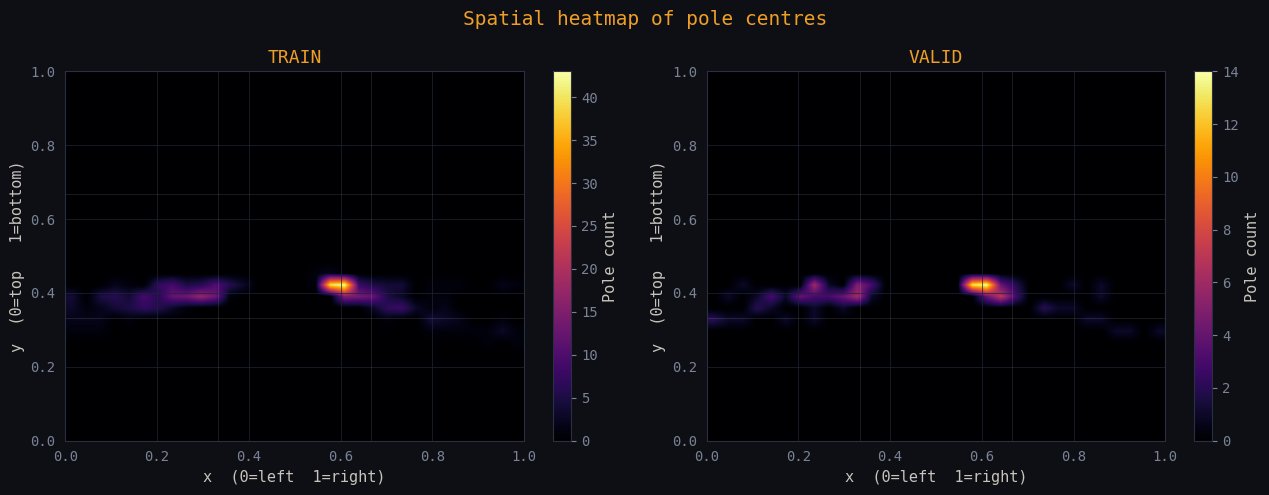


  Left-half poles : 235
  Right-half poles: 270
  L/R ratio       : 0.87
  → Distribution is roughly symmetric. Horizontal flip is SAFE.


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Spatial heatmap of pole centres", color=ACCENT, fontsize=14)

for ax, split in zip(axes, SPLITS):
    sub = boxes_df[boxes_df["split"] == split]
    heatmap, xedges, yedges = np.histogram2d(
        sub["cx"], sub["cy"], bins=32, range=[[0,1],[0,1]]
    )
    im = ax.imshow(
        heatmap.T, origin="upper",
        extent=[0, 1, 0, 1],
        cmap="inferno", aspect="auto",
        interpolation="bilinear"
    )
    plt.colorbar(im, ax=ax, label="Pole count")
    ax.set_title(split.upper())
    ax.set_xlabel("x  (0=left  1=right)")
    ax.set_ylabel("y  (0=top   1=bottom)")
    # Overlay grid thirds
    for v in [1/3, 2/3]:
        ax.axvline(v, color="white", alpha=0.15, linewidth=0.5)
        ax.axhline(v, color="white", alpha=0.15, linewidth=0.5)

plt.tight_layout()
plt.savefig("eda_spatial_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Symmetry check: compare left vs right half counts
left  = (boxes_df["cx"] < 0.5).sum()
right = (boxes_df["cx"] >= 0.5).sum()
ratio = left / (right + 1e-6)
print(f"\n  Left-half poles : {left}")
print(f"  Right-half poles: {right}")
print(f"  L/R ratio       : {ratio:.2f}")
if 0.8 <= ratio <= 1.2:
    print("  → Distribution is roughly symmetric. Horizontal flip is SAFE.")
else:
    print("  → Asymmetric distribution. Consider disabling fliplr augmentation.")

## 6. Image Quality — Blur & Brightness

**Blur (Laplacian variance):** High = sharp, Low = blurry/foggy. Winter driving produces significant motion blur. If the dataset has many blurry images we should add blur augmentation to the training pipeline so the model generalises to these conditions.

**Brightness:** Bimodal distribution means both very dark and very bright conditions are present, justifying large brightness/contrast jitter.

In [25]:
def compute_quality(img_path: Path):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return 0.0, 0.0
    blur       = float(cv2.Laplacian(img, cv2.CV_64F).var())
    brightness = float(img.mean())
    return blur, brightness

# Cap at 500 images per split for speed
CAP = 500
quality_rows = []
for split in SPLITS:
    sample = dfs[split].head(CAP)
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc=f"Quality {split}"):
        blur, brightness = compute_quality(row["img_path"])
        quality_rows.append({"split": split, "blur": blur, "brightness": brightness})

quality_df = pd.DataFrame(quality_rows)
print(quality_df.groupby("split")[["blur","brightness"]].describe().round(2))

Quality valid: 100%|██████████| 92/92 [00:02<00:00, 42.85it/s]

        blur                                                brightness         \
       count   mean    std   min   25%    50%    75%    max      count   mean   
split                                                                           
train  322.0  18.38  15.29  4.25  7.92  11.18  24.52  93.81      322.0  93.84   
valid   92.0  17.39  14.79  4.40  7.65  10.36  21.59  76.92       92.0  92.47   

                                                 
        std    min    25%    50%    75%     max  
split                                            
train  7.86  71.82  89.21  91.83  96.96  143.80  
valid  5.65  69.45  88.92  90.83  95.89  112.63  


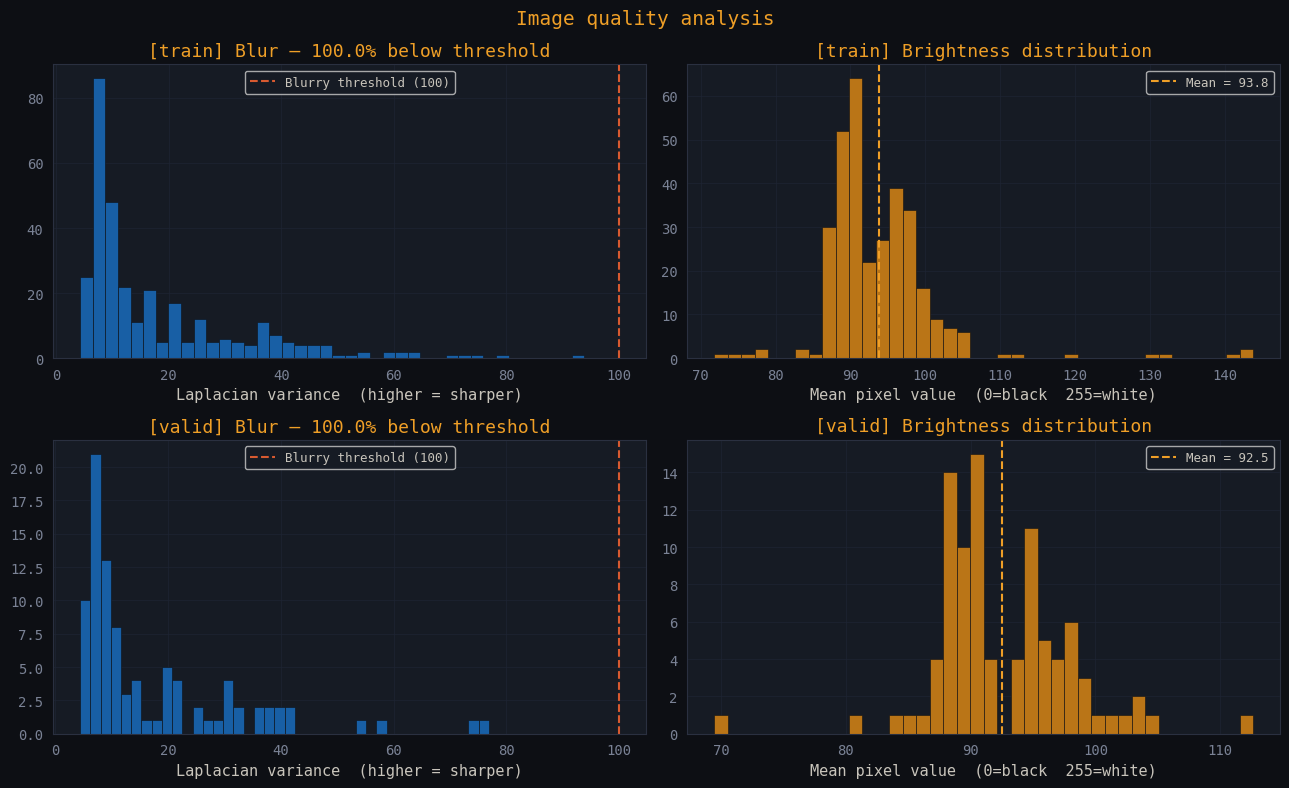

  100.0% of images are blurry → add blur augmentation (aug_blur=0.3+)


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Image quality analysis", color=ACCENT, fontsize=14)

for row_i, split in enumerate(SPLITS):
    sub = quality_df[quality_df["split"] == split]

    # Blur histogram
    ax = axes[row_i, 0]
    ax.hist(sub["blur"], bins=40, color="#185fa5", edgecolor="#0d0f14", linewidth=0.4)
    ax.axvline(100, color=DANGER, linestyle="--", label="Blurry threshold (100)")
    blurry_pct = (sub["blur"] < 100).mean() * 100
    ax.set_title(f"[{split}] Blur — {blurry_pct:.1f}% below threshold")
    ax.set_xlabel("Laplacian variance  (higher = sharper)")
    ax.legend(fontsize=9)

    # Brightness histogram
    ax = axes[row_i, 1]
    ax.hist(sub["brightness"], bins=40, color="#ba7517", edgecolor="#0d0f14", linewidth=0.4)
    ax.axvline(sub["brightness"].mean(), color=ACCENT, linestyle="--",
               label=f"Mean = {sub['brightness'].mean():.1f}")
    ax.set_title(f"[{split}] Brightness distribution")
    ax.set_xlabel("Mean pixel value  (0=black  255=white)")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("eda_image_quality.png", dpi=150, bbox_inches="tight")
plt.show()

# Augmentation recommendation
train_blur = quality_df[quality_df["split"]=="train"]["blur"]
blurry_train = (train_blur < 100).mean() * 100
if blurry_train > 15:
    print(f"  {blurry_train:.1f}% of images are blurry → add blur augmentation (aug_blur=0.3+)")
else:
    print(f"  Only {blurry_train:.1f}% are blurry → modest blur aug (aug_blur=0.1) sufficient")

## 7. Sample Visualisation with Labels

Always look at your data. Inspect label quality — are there missing poles, wrong boxes, label drift?

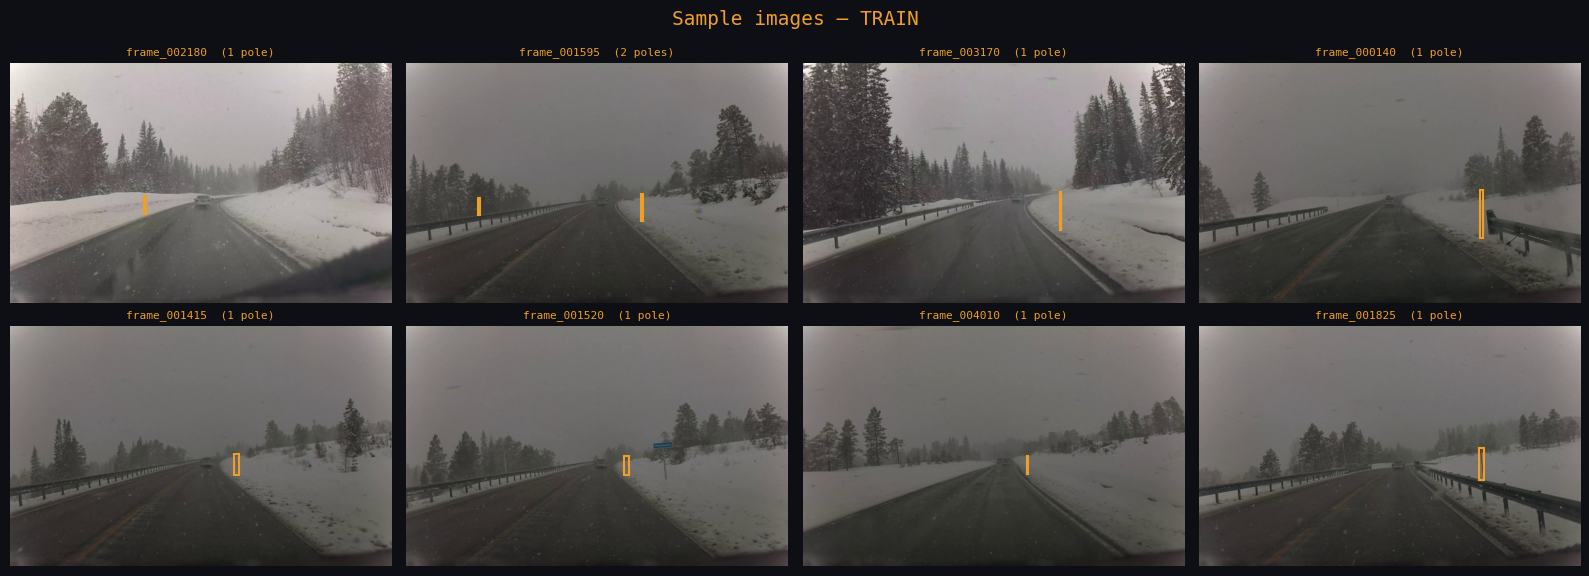

ValueError: Number of rows must be a positive integer, not 0

<Figure size 1600x0 with 0 Axes>

In [27]:
def show_samples(df: pd.DataFrame, split: str, n: int = 8,
                 only_with_poles: bool = False):
    sub = df[df["split"] == split]
    if only_with_poles:
        sub = sub[sub["n_poles"] > 0]
    sample = sub.sample(min(n, len(sub)), random_state=SEED)

    cols = 4
    rows = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
    fig.suptitle(f"Sample images — {split.upper()}", color=ACCENT, fontsize=14)
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = np.array(Image.open(row["img_path"]).convert("RGB"))
        ax.imshow(img)

        H, W = img.shape[:2]
        for (cx, cy, bw, bh) in row["boxes"]:
            x1 = (cx - bw/2) * W
            y1 = (cy - bh/2) * H
            rect = patches.Rectangle(
                (x1, y1), bw*W, bh*H,
                linewidth=1.5, edgecolor="#ef9f27", facecolor="none"
            )
            ax.add_patch(rect)

        n_p = row["n_poles"]
        ax.set_title(f"{row['stem'][:20]}  ({n_p} pole{'s' if n_p!=1 else ''})",
                     fontsize=8, color="#ef9f27" if n_p > 0 else "#7a8295")
        ax.axis("off")

    for ax in axes[len(sample):]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(f"eda_samples_{split}.png", dpi=120, bbox_inches="tight")
    plt.show()

show_samples(df_all, "train", n=8)
show_samples(df_all, "val",   n=8)

Images with at least one tiny pole: 364


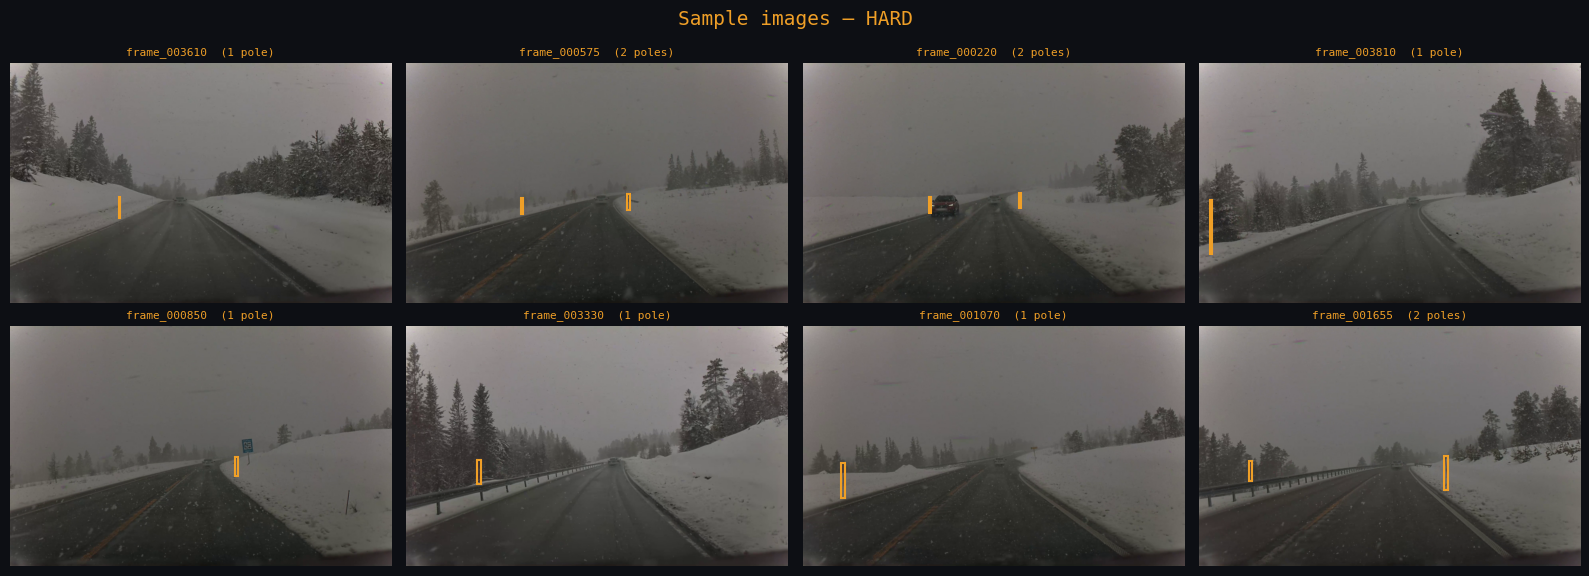

In [28]:
# Show the HARDEST images — very small poles or crowded scenes
tiny_threshold = 32 / 640   # 32px at 640 input

hard_cases = []
for _, row in df_all.iterrows():
    scales = [np.sqrt(b[2]*b[3]) for b in row["boxes"]]
    if scales and min(scales) < tiny_threshold:
        hard_cases.append(row)

hard_df = pd.DataFrame(hard_cases)
print(f"Images with at least one tiny pole: {len(hard_df)}")
if len(hard_df) > 0:
    show_samples(hard_df.assign(split="hard"), "hard", n=8)

## 8. Summary & Model Decision Table

Everything above feeds directly into training decisions. Run this cell last — it summarises your findings.

In [29]:
# ── Compute summary stats ─────────────────────────────────────────────────────
train_boxes = boxes_df[boxes_df["split"] == "train"]
tiny_pct    = (train_boxes["scale"] < 32/640).mean() * 100
small_pct   = (train_boxes["scale"] < 96/640).mean() * 100
med_aspect  = train_boxes["aspect"].median()
lr_ratio    = left / (right + 1e-6)
blurry_pct  = (quality_df[quality_df["split"]=="train"]["blur"] < 100).mean() * 100
mean_bright = quality_df[quality_df["split"]=="train"]["brightness"].mean()
empty_pct   = (dfs["train"]["n_poles"] == 0).mean() * 100

decisions = [
    ("Tiny poles (< 32px @ 640)",
     f"{tiny_pct:.1f}%",
     "imgsz=1280" if tiny_pct > 20 else "imgsz=640 (ok)"),

    ("Median aspect ratio (w/h)",
     f"{med_aspect:.3f}",
     "flipud=0.0  (never flip vertically)"),

    ("L/R symmetry ratio",
     f"{lr_ratio:.2f}",
     "fliplr=0.5 (safe)" if 0.8 <= lr_ratio <= 1.2 else "fliplr=0.0 (asymmetric!)"),

    ("Blurry images",
     f"{blurry_pct:.1f}%",
     "aug_blur=0.3" if blurry_pct > 15 else "aug_blur=0.1"),

    ("Mean brightness",
     f"{mean_bright:.1f} / 255",
     "hsv_v=0.5, strong brightness jitter" if mean_bright < 100 else "hsv_v=0.4"),

    ("Empty images (no poles)",
     f"{empty_pct:.1f}%",
     "Expect FP pressure → tune conf threshold carefully"),
]

print("\n" + "═" * 72)
print(f"  {'Finding':<35} {'Value':>10}    Decision")
print("═" * 72)
for finding, value, decision in decisions:
    print(f"  {finding:<35} {value:>10}    {decision}")
print("═" * 72)
print("\nThese findings should be cited in your report presentation.")
print("Each augmentation/architecture choice needs a data-driven justification.")


════════════════════════════════════════════════════════════════════════
  Finding                                  Value    Decision
════════════════════════════════════════════════════════════════════════
  Tiny poles (< 32px @ 640)                87.0%    imgsz=1280
  Median aspect ratio (w/h)                0.067    flipud=0.0  (never flip vertically)
  L/R symmetry ratio                        0.87    fliplr=0.5 (safe)
  Blurry images                           100.0%    aug_blur=0.3
  Mean brightness                     93.8 / 255    hsv_v=0.5, strong brightness jitter
  Empty images (no poles)                   0.0%    Expect FP pressure → tune conf threshold carefully
════════════════════════════════════════════════════════════════════════

These findings should be cited in your report presentation.
Each augmentation/architecture choice needs a data-driven justification.
